<a href="https://colab.research.google.com/github/tanmayrathi/ML_PROJECT_TAE1/blob/main/XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# STEP 1: Mount Google Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# STEP 2: Install XGBoost
# =========================
!pip install xgboost


In [3]:
# STEP 3: Import Libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

In [5]:
# STEP 4: Load Dataset
# =========================
file_path = '/content/drive/MyDrive/ML_datasets/healthcare-dataset-stroke-data.csv'   # change this
df = pd.read_csv(file_path)

In [6]:
print(df.head())

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


In [7]:
# STEP 5: Preprocessing
# =========================

# Handle missing values
df = df.dropna()

# Encode categorical data
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])


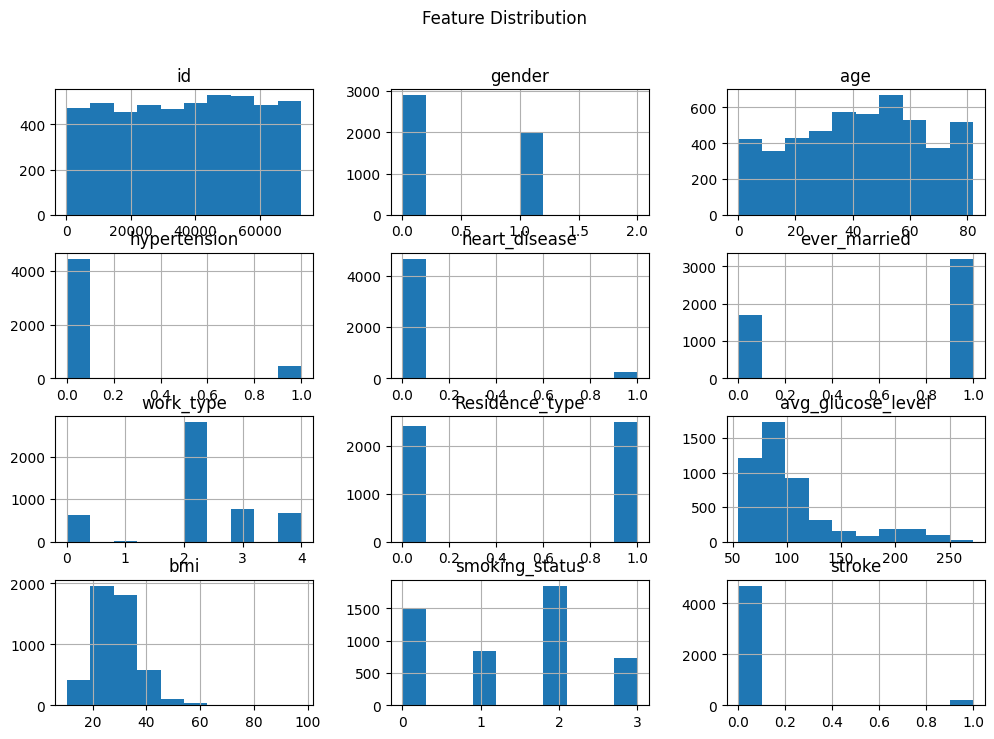

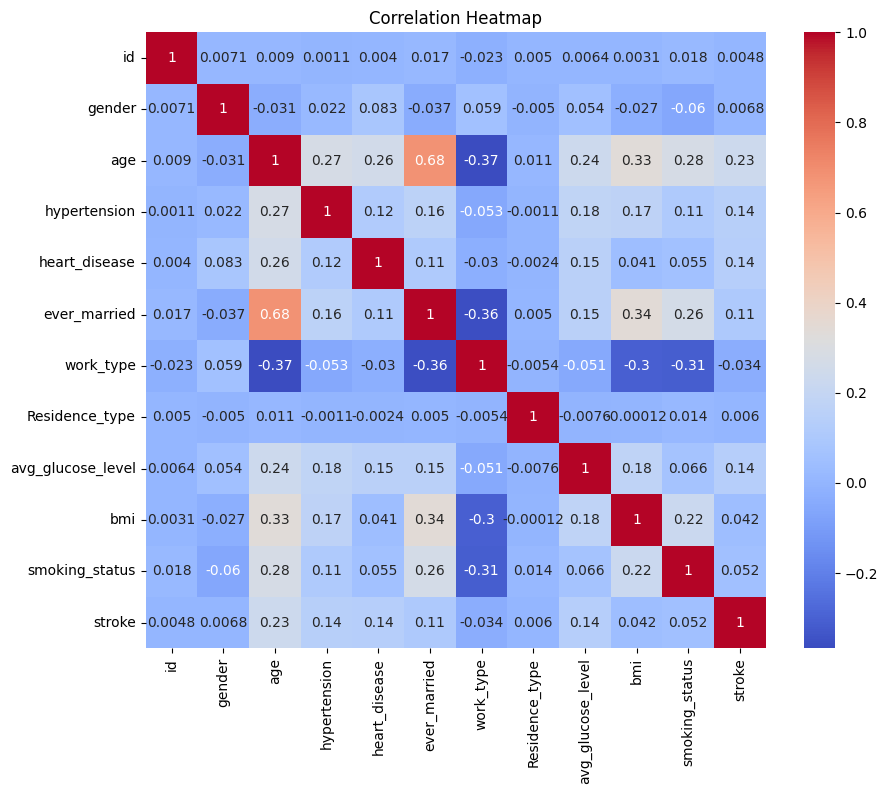

In [8]:
# STEP 6: EDA Visualization
# =========================

# Feature distribution
df.hist(figsize=(12,8))
plt.suptitle("Feature Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [9]:
# STEP 7: Split Features & Target
# =========================
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [10]:
# Scaling (optional for XGBoost but good practice)
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [11]:
# STEP 8: Train-Test Split Loop + ETA
# =========================

split_ratios = [0.3, 0.2]   # 70:30 and 80:20
eta_values = [0.01, 0.1, 0.3]   # learning rates

for test_size in split_ratios:

    print("\n==============================")
    print(f"Train-Test Split: {int((1-test_size)*100)}:{int(test_size*100)}")
    print("==============================")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    for eta in eta_values:

        print(f"\n--- ETA (learning rate): {eta} ---")


Train-Test Split: 70:30

--- ETA (learning rate): 0.01 ---

--- ETA (learning rate): 0.1 ---

--- ETA (learning rate): 0.3 ---

Train-Test Split: 80:20

--- ETA (learning rate): 0.01 ---

--- ETA (learning rate): 0.1 ---

--- ETA (learning rate): 0.3 ---


In [14]:
# STEP 9: XGBoost Model
model = XGBClassifier(
    learning_rate=eta,
    n_estimators=100,
    max_depth=4,
    use_label_encoder=False,
    eval_metric='logloss'
)


In [22]:
# STEP 10: Prediction
# =========================
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Done for eta:", eta)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:23:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Done for eta: 0.3


In [23]:
# STEP 11: Evaluation
# =========================
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9439918533604889
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       929
           1       0.25      0.02      0.04        53

    accuracy                           0.94       982
   macro avg       0.60      0.51      0.50       982
weighted avg       0.91      0.94      0.92       982



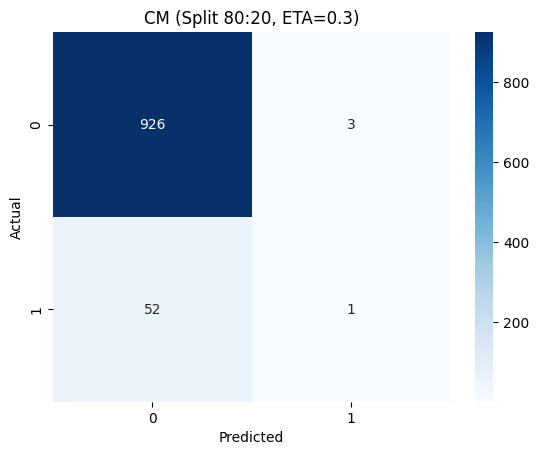

In [29]:
        cm = confusion_matrix(y_test, y_pred)#visualization

        plt.figure()
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'CM (Split {int((1-test_size)*100)}:{int(test_size*100)}, ETA={eta})')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()